# Baseline Models: TF-IDF + Logistic Regression / Linear SVM

Train and evaluate two baseline models on the Russian toxic comments dataset.

In [2]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

sys.path.insert(0, os.path.join(os.getcwd(), ".."))

from src.baselines import build_logreg_pipeline, build_svm_pipeline
from src.evaluation import compute_metrics, print_report, plot_confusion_matrix, plot_roc_curve, save_metrics

sns.set_theme(style="whitegrid")
print("Imports done.")

Imports done.


## 1. Load Data Splits

In [3]:
train_df = pd.read_csv("../data/train.csv")
val_df = pd.read_csv("../data/val.csv")
test_df = pd.read_csv("../data/test.csv")

X_train = train_df["clean_comment"].fillna("")
y_train = train_df["toxic"]
X_val = val_df["clean_comment"].fillna("")
y_val = val_df["toxic"]
X_test = test_df["clean_comment"].fillna("")
y_test = test_df["toxic"]

print(f"Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")
print(f"Toxic %: train={y_train.mean()*100:.1f}%  val={y_val.mean()*100:.1f}%  test={y_test.mean()*100:.1f}%")

Train: 10088  |  Val: 2162  |  Test: 2162
Toxic %: train=33.5%  val=33.5%  test=33.5%


## 2. Train Logistic Regression

In [4]:
logreg = build_logreg_pipeline()

start = time.time()
logreg.fit(X_train, y_train)
train_time_lr = time.time() - start
print(f"Logistic Regression trained in {train_time_lr:.1f}s")

# Validation set predictions
y_val_pred_lr = logreg.predict(X_val)
y_val_prob_lr = logreg.predict_proba(X_val)[:, 1]

print("\n--- Validation Set Results ---")
print_report(y_val, y_val_pred_lr)
val_metrics_lr = compute_metrics(y_val, y_val_pred_lr, y_val_prob_lr)
print(f"ROC-AUC: {val_metrics_lr['roc_auc']:.4f}")

Logistic Regression trained in 0.8s

--- Validation Set Results ---
              precision    recall  f1-score   support

   Non-toxic       0.79      0.97      0.87      1438
       Toxic       0.88      0.49      0.63       724

    accuracy                           0.81      2162
   macro avg       0.84      0.73      0.75      2162
weighted avg       0.82      0.81      0.79      2162

ROC-AUC: 0.9153


## 3. Train Linear SVM

In [5]:
svm = build_svm_pipeline()

start = time.time()
svm.fit(X_train, y_train)
train_time_svm = time.time() - start
print(f"Linear SVM trained in {train_time_svm:.1f}s")

# Validation set predictions
y_val_pred_svm = svm.predict(X_val)
y_val_prob_svm = svm.predict_proba(X_val)[:, 1]

print("\n--- Validation Set Results ---")
print_report(y_val, y_val_pred_svm)
val_metrics_svm = compute_metrics(y_val, y_val_pred_svm, y_val_prob_svm)
print(f"ROC-AUC: {val_metrics_svm['roc_auc']:.4f}")

Linear SVM trained in 0.7s

--- Validation Set Results ---
              precision    recall  f1-score   support

   Non-toxic       0.86      0.93      0.89      1438
       Toxic       0.83      0.70      0.76       724

    accuracy                           0.85      2162
   macro avg       0.85      0.81      0.83      2162
weighted avg       0.85      0.85      0.85      2162

ROC-AUC: 0.9215


## 4. Test Set Evaluation

In [6]:
# Logistic Regression on test set
y_test_pred_lr = logreg.predict(X_test)
y_test_prob_lr = logreg.predict_proba(X_test)[:, 1]
test_metrics_lr = compute_metrics(y_test, y_test_pred_lr, y_test_prob_lr)

# SVM on test set
y_test_pred_svm = svm.predict(X_test)
y_test_prob_svm = svm.predict_proba(X_test)[:, 1]
test_metrics_svm = compute_metrics(y_test, y_test_pred_svm, y_test_prob_svm)

print("=" * 60)
print("LOGISTIC REGRESSION — Test Set")
print("=" * 60)
print_report(y_test, y_test_pred_lr)
print(f"ROC-AUC: {test_metrics_lr['roc_auc']:.4f}\n")

print("=" * 60)
print("LINEAR SVM — Test Set")
print("=" * 60)
print_report(y_test, y_test_pred_svm)
print(f"ROC-AUC: {test_metrics_svm['roc_auc']:.4f}")

LOGISTIC REGRESSION — Test Set
              precision    recall  f1-score   support

   Non-toxic       0.80      0.97      0.88      1438
       Toxic       0.90      0.51      0.65       724

    accuracy                           0.82      2162
   macro avg       0.85      0.74      0.76      2162
weighted avg       0.83      0.82      0.80      2162

ROC-AUC: 0.9120

LINEAR SVM — Test Set
              precision    recall  f1-score   support

   Non-toxic       0.86      0.94      0.90      1438
       Toxic       0.85      0.71      0.77       724

    accuracy                           0.86      2162
   macro avg       0.86      0.82      0.84      2162
weighted avg       0.86      0.86      0.86      2162

ROC-AUC: 0.9193


## 5. Confusion Matrices

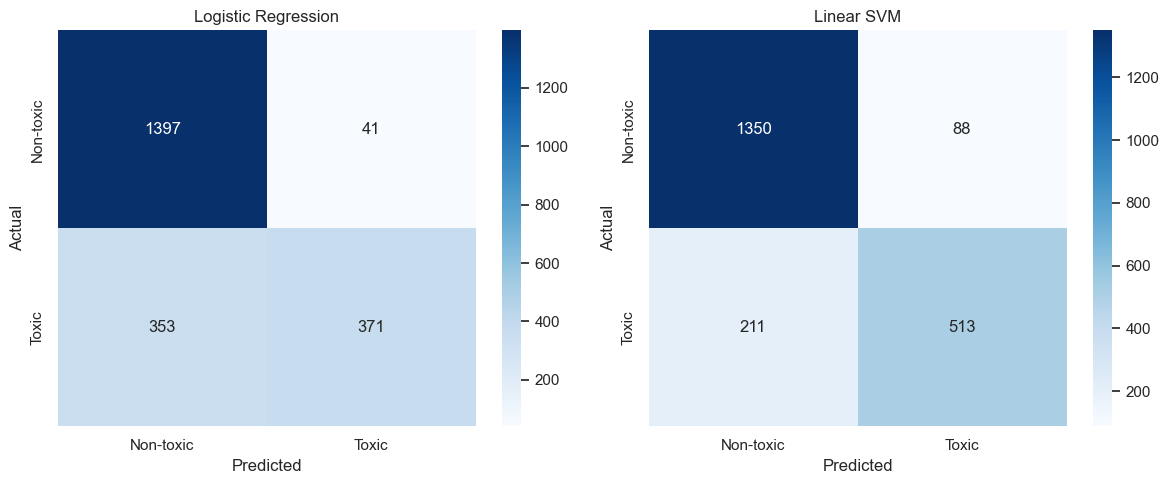

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

plot_confusion_matrix(y_test, y_test_pred_lr, title="Logistic Regression", ax=axes[0])
plot_confusion_matrix(y_test, y_test_pred_svm, title="Linear SVM", ax=axes[1])

plt.tight_layout()
plt.show()

## 6. ROC Curves

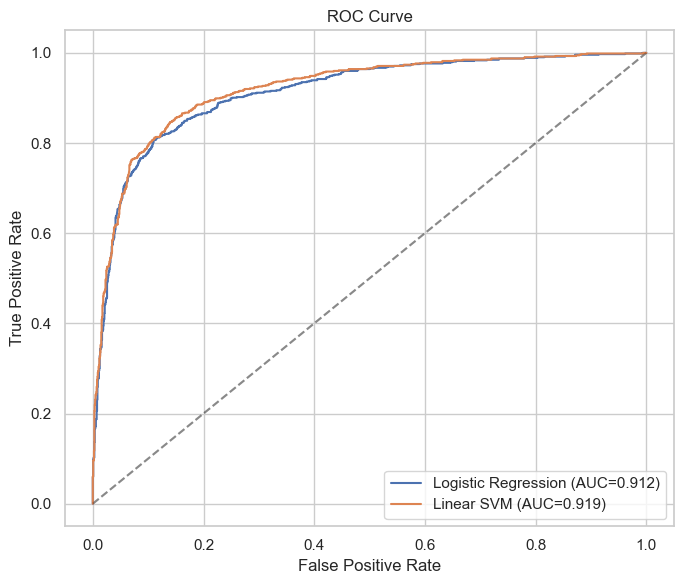

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))

plot_roc_curve(y_test, y_test_prob_lr, label="Logistic Regression", ax=ax)
plot_roc_curve(y_test, y_test_prob_svm, label="Linear SVM", ax=ax)

plt.tight_layout()
plt.show()

## 7. Results Comparison

In [9]:
comparison = pd.DataFrame({
    "Logistic Regression": test_metrics_lr,
    "Linear SVM": test_metrics_svm,
}).round(4)

comparison

,Logistic Regression,Linear SVM
accuracy,0.8178,0.8617
precision_nontoxic,0.7983,0.8648
recall_nontoxic,0.9715,0.9388
f1_nontoxic,0.8764,0.9003
precision_toxic,0.9005,0.8536
recall_toxic,0.5124,0.7086
f1_toxic,0.6532,0.7743
precision_macro,0.8494,0.8592
recall_macro,0.7420,0.8237
f1_macro,0.7648,0.8373


## 8. Save Metrics

In [10]:
all_metrics = {
    "logistic_regression": {
        "val": val_metrics_lr,
        "test": test_metrics_lr,
        "train_time_seconds": round(train_time_lr, 2),
        "hyperparameters": {
            "max_features": 50000,
            "ngram_range": [1, 2],
            "C": 1.0,
            "solver": "lbfgs",
            "sublinear_tf": True,
        },
    },
    "linear_svm": {
        "val": val_metrics_svm,
        "test": test_metrics_svm,
        "train_time_seconds": round(train_time_svm, 2),
        "hyperparameters": {
            "max_features": 50000,
            "ngram_range": [1, 2],
            "C": 1.0,
            "sublinear_tf": True,
            "calibration_cv": 3,
        },
    },
}

save_metrics(all_metrics, "../results/baseline_metrics.json")
print("Done!")

Metrics saved to ../results/baseline_metrics.json
Done!
